# Filter lightcurve

2 of 3

In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


## Download


In [2]:
download_chandra_obsid 1712,3103 evt2

mv -f 1712/primary/acisf01712N004_evt2.fits.gz .
gunzip -f acisf01712N004_evt2.fits.gz
rmdir -p 1712/primary

mv -f 3103/primary/acisf03103N004_evt2.fits.gz .
gunzip -f acisf03103N004_evt2.fits.gz
rmdir -p 3103/primary


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  evt2     fits       16 Mb  ####################          < 1 s  28171.5 kb/s


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  evt2     fits      945 Kb  ####################          < 1 s  10450.8 kb/s



In [3]:
dmcopy "acisf01712N004_evt2.fits[energy=500:7000,ccd_id=7]" evt2_c7.fits  cl+

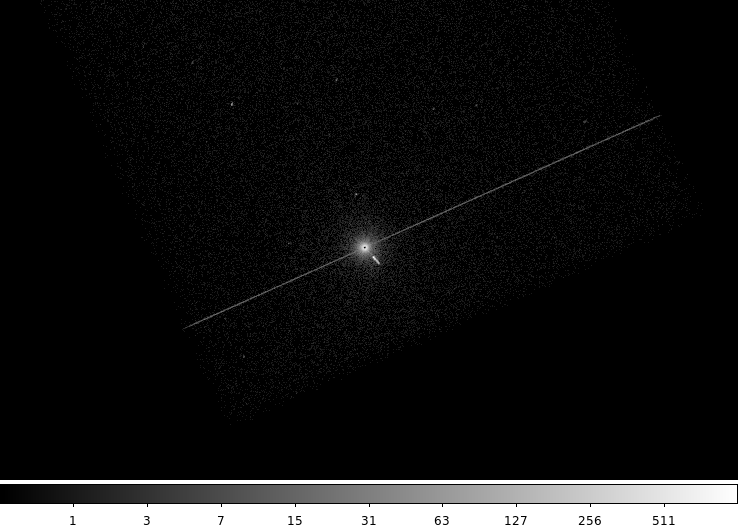

In [4]:
ds9 evt2_c7.fits -bin factor 2 -scale log -saveimage png ds9_01.png -quit
display < ds9_01.png

## Remove bright source

In [5]:
cat << EOM > exclude.reg
# Region file format: CIAO version 1.0
rotbox(4200.3328,4137.9892,1129.5056,74.07019,24.22333)
circle(4076.5,4088.5,316)
circle(4296.5,5024.5,48)
EOM

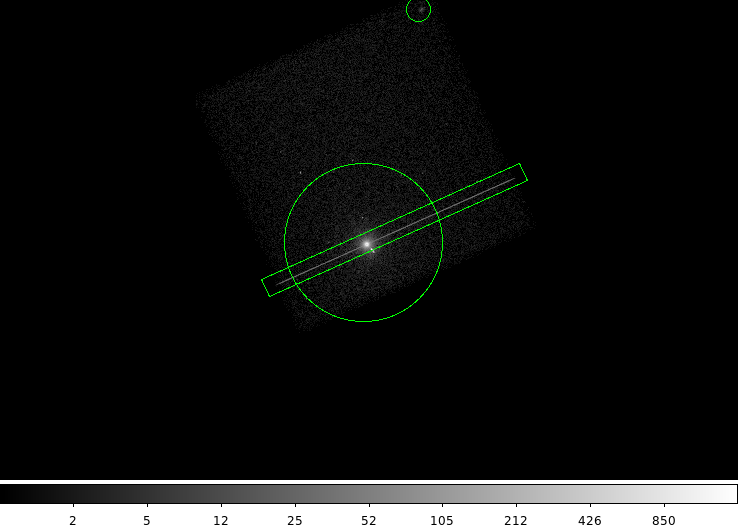

In [6]:
ds9 evt2_c7.fits -region exclude.reg -bin factor 4 -scale log -saveimage png ds9_02.png -quit
display < ds9_02.png

## Create lightcurve


In [7]:
pset dmextract "evt2_c7.fits[exclude sky=region(exclude.reg)][bin time=::200]" 
pset dmextract outfile=lc_c7.fits
pset dmextract opt=ltc1
dmextract mode=h clob+

## Analyze the lightcurve using lc_sigma_clip()

Parameters used to clean the lightcurve are:
  script version = October 2016
  clipping       = symmetric
  sigma          = 3
  minlength      = 3
  plot           = True
  rateaxis       = y
  color          = green

Total number of bins in lightcurve   = 153
Max length of one bin                = 197.467 s
Num. bins with a smaller exp. time   = 2
Num. bins with exp. time = 0         = 13
Number of bins with a rate of 0 ct/s = 13

Rate filter:  -0.10548253792390716 <= count_rate < 1.023444242498134 
Mean level of filtered lightcurve = 0.45898085228711338 ct/s

         1151.582025 bins.
         Replacing with a width of 0.0115158 count/s
         This may indicate that the lightcurve contains strong flares that
         require manual filtering.

GTI limits calculated using a count-rate filter:
  (count_rate>-0.10548253792390716 && count_rate<1.023444242498134)

The corresponding times are:
  ((time >= 77379470.949928001) && (time < 77399470.949928001)) ; 19.59 ksec, bin 1
  ((time 

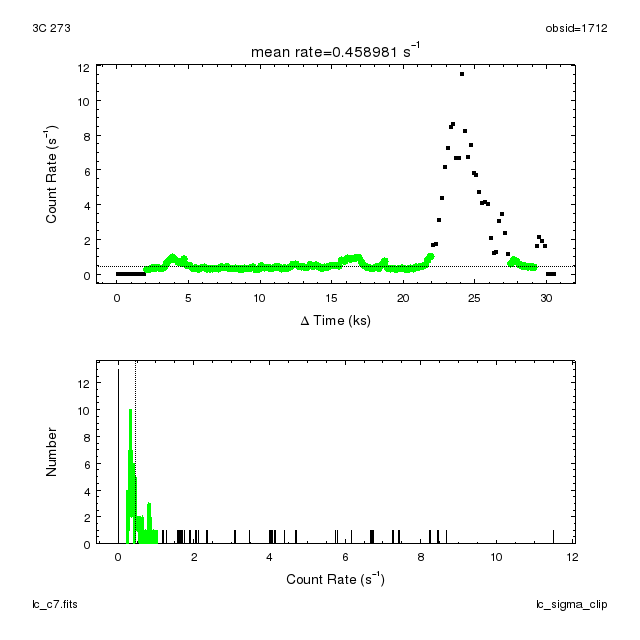

In [8]:
cat << EOM > c1.py
from lightcurves import *
lc_sigma_clip("lc_c7.fits")
print_window("chips_01.png","export.clobber=True")
quit()
EOM

chips -b c1.py
display < chips_01.png 

Parameters used to clean the lightcurve are:
  script version = October 2016
  clipping       = symmetric
  sigma          = 3
  minlength      = 3
  plot           = True
  rateaxis       = y
  color          = green

Total number of bins in lightcurve   = 130
Max length of one bin                = 197.467 s
Num. bins with a smaller exp. time   = 2
Num. bins with exp. time = 0         = 13
Number of bins with a rate of 0 ct/s = 13

Rate filter:  -0.10548253792390716 <= count_rate < 1.023444242498134 
Mean level of filtered lightcurve = 0.45898085228711338 ct/s

GTI limits calculated using a count-rate filter:
  (count_rate>-0.10548253792390716 && count_rate<1.023444242498134)

The corresponding times are:
  ((time >= 77379470.949928001) && (time < 77399470.949928001)) ; 19.59 ksec, bin 1
  ((time >= 77404870.949928001) && (time < 77406670.949928001)) ; 1.78 ksec, bin 2

  Exposure time of lightcurve = 27.45 ks
  Filtered exposure time      = 21.36 ks
  DTCOR value                 = 0.

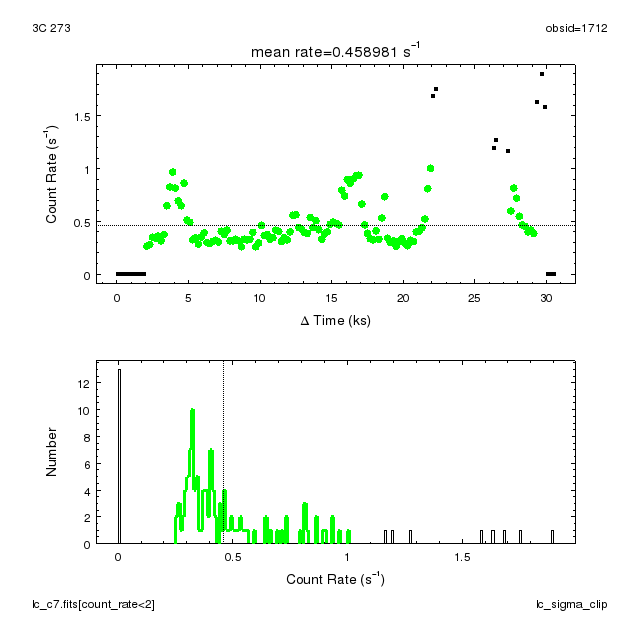

In [9]:
cat << EOM > c2.py
from lightcurves import *
lc_sigma_clip("lc_c7.fits[count_rate<2]")
print_window("chips_02.png","export.clobber=True")
quit()
EOM

chips -b c2.py
display < chips_02.png 

## Running lc_sigma_clip via the deflare script

In [10]:
deflare "lc_c7.fits[count_rate<2]" outfile=lc_c7.gti method=sigma

Parameters used to clean the lightcurve are:
  script version = October 2016
  clipping       = symmetric
  sigma          = 3
  minlength      = 3
  outfile        = lc_c7.gti
  plot           = False
  rateaxis       = y
  color          = green
  pattern        = solid
  pattern color  = red

Total number of bins in lightcurve   = 130
Max length of one bin                = 197.467 s
Num. bins with a smaller exp. time   = 2
Num. bins with exp. time = 0         = 13
Number of bins with a rate of 0 ct/s = 13

Rate filter:  -0.10548253792390716 <= count_rate < 1.023444242498134 
Mean level of filtered lightcurve = 0.45898085228711338 ct/s

GTI limits calculated using a count-rate filter:
  (count_rate>-0.10548253792390716 && count_rate<1.023444242498134)

The corresponding times are:
  ((time >= 77379470.949928001) && (time < 77399470.949928001)) ; 19.59 ksec, bin 1
  ((time >= 77404870.949928001) && (time < 77406670.949928001)) ; 1.78 ksec, bin 2

  Exposure time of lightcurve = 27.45 

## Change obsid -- 3103


In [11]:
celldetect acisf03103N004_evt2.fits"[energy=500:7000]" \
  outfile=cell.src ellsig=5 mode=h clob+

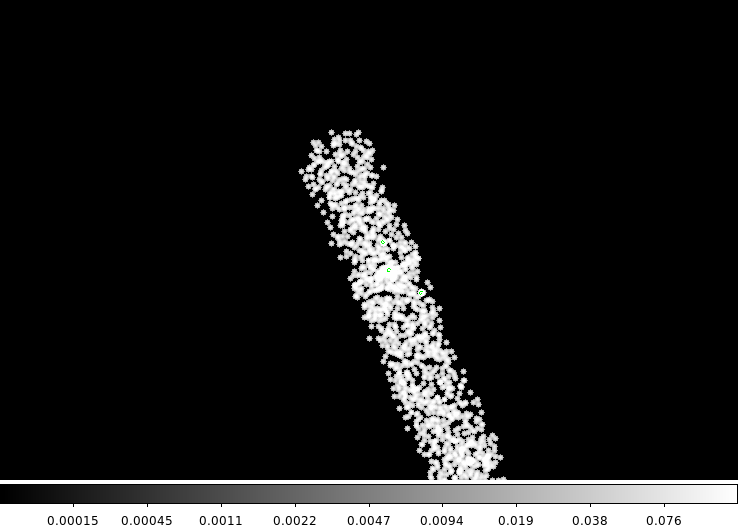

In [12]:
ds9 acisf03103N004_evt2.fits"[events,energy=500:7000]" -region cell.src \
  -bin factor 2 -scale log -scale mode 99.5 -smooth \
  -saveimage png ds9_03.png -quit
display < ds9_03.png

In [13]:
dmextract acisf03103N004_evt2.fits"[exclude sky=region(cell.src)][bin time=::500]" \
  acis3103_500s.lc op=ltc1 mode=h clob+

## Okay, now back to the thread

In [14]:
deflare acis3103_500s.lc outfile=3103.gti method="sigma" plot=yes < /dev/null

Parameters used to clean the lightcurve are:
  script version = October 2016
  clipping       = symmetric
  sigma          = 3
  minlength      = 3
  outfile        = 3103.gti
  plot           = True
  rateaxis       = y
  color          = green
  pattern        = solid
  pattern color  = red

Total number of bins in lightcurve   = 83
Max length of one bin                = 453.474 s
Num. bins with a smaller exp. time   = 8
Num. bins with exp. time = 0         = 2
Number of bins with a rate of 0 ct/s = 2

Rate filter:  0.39876060089782156 <= count_rate < 0.62382997347969615 
Mean level of filtered lightcurve = 0.51129528718875883 ct/s

GTI limits calculated using a count-rate filter:
  (count_rate>0.39876060089782156 && count_rate<0.62382997347969615)

The corresponding times are:
  ((time >= 126705607.39342) && (time < 126707107.39342)) ; 0.97 ksec, bin 1
  ((time >= 126707607.39342) && (time < 126746107.39342)) ; 34.79 ksec, bin 2

  Exposure time of lightcurve = 36.21 ks
  Filtered e

In [15]:
deflare acis3103_500s.lc outfile=3103_1.6.gti method="sigma" plot=yes nsigma=2 < /dev/null

Parameters used to clean the lightcurve are:
  script version = October 2016
  clipping       = symmetric
  sigma          = 2
  minlength      = 3
  outfile        = 3103_1.6.gti
  plot           = True
  rateaxis       = y
  color          = green
  pattern        = solid
  pattern color  = red

Total number of bins in lightcurve   = 83
Max length of one bin                = 453.474 s
Num. bins with a smaller exp. time   = 8
Num. bins with exp. time = 0         = 2
Number of bins with a rate of 0 ct/s = 2

Rate filter:  0.45418515651036134 <= count_rate < 0.56717130060625931 
Mean level of filtered lightcurve = 0.51067822855831035 ct/s

GTI limits calculated using a time filter:
  ((time >= 126705607.39342) && (time < 126707107.39342)) ; 0.97 ksec, bin 1
  ((time >= 126707607.39342) && (time < 126709107.39342)) ; 1.36 ksec, bin 2
  ((time >= 126709607.39342) && (time < 126712607.39342)) ; 2.72 ksec, bin 3
  ((time >= 126713107.39342) && (time < 126715107.39342)) ; 1.81 ksec, bin 4
  

## Filtering the event file

### 1. Using lc_sigma_clip

Parameters used to clean the lightcurve are:
  script version = October 2016
  clipping       = symmetric
  sigma          = 3
  minlength      = 3
  outfile        = lc_c7.gti
  plot           = True
  rateaxis       = y
  color          = green
  pattern        = solid
  pattern color  = red

Total number of bins in lightcurve   = 130
Max length of one bin                = 197.467 s
Num. bins with a smaller exp. time   = 2
Num. bins with exp. time = 0         = 13
Number of bins with a rate of 0 ct/s = 13

Rate filter:  -0.10548253792390716 <= count_rate < 1.023444242498134 
Mean level of filtered lightcurve = 0.45898085228711338 ct/s

GTI limits calculated using a count-rate filter:
  (count_rate>-0.10548253792390716 && count_rate<1.023444242498134)

The corresponding times are:
  ((time >= 77379470.949928001) && (time < 77399470.949928001)) ; 19.59 ksec, bin 1
  ((time >= 77404870.949928001) && (time < 77406670.949928001)) ; 1.78 ksec, bin 2

  Exposure time of lightcurve = 27.45 k

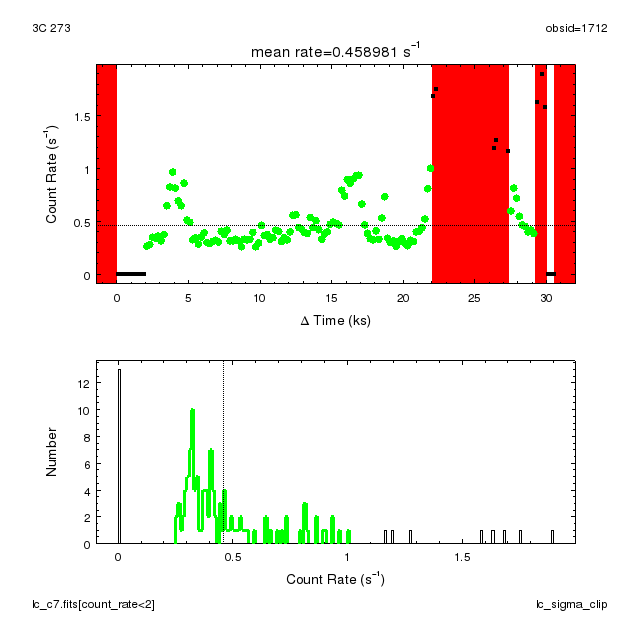

In [16]:
cat << EOM > c3.py
from lightcurves import *
lc_sigma_clip("lc_c7.fits[count_rate<2]", outfile="lc_c7.gti")
print_window("chips_03.png","export.clobber=True")
quit()
EOM

chips -b c3.py
display < chips_03.png 

In [17]:
dmcopy "evt2_c7.fits[@lc_c7.gti]" evt2_c7_lc.fits clob+

### 2. Using dmgti

In [18]:
pset dmgti infile=lc_c7.fits
pset dmgti outfile=lc_c7.dmgti.gti
pset dmgti userlimit="((time >= 77379470.949928) && (time < 77399470.949928))||((time >= 77404870.949928) && (time < 77406670.949928))"
dmgti mode=h clobber=yes

In [19]:
dmcopy "evt2_c7.fits[@lc_c7.dmgti.gti]" evt2_c7_dmgti.fits clob+

### 3. Using a DM filter

In [20]:
dmcopy "evt2_c7.fits[time=77379470.949928:77399470.949928,77404870.949928:77406670.949928]" \
      evt2_c7_dmcopy.fits clob+

## Check `EXPOSURE` time

In [21]:
dmkeypar evt2_c7_lc.fits EXPOSURE echo+

21364.401548125


In [22]:
dmkeypar evt2_c7_dmgti.fits EXPOSURE echo+

21364.401548125


In [23]:
dmkeypar evt2_c7_dmcopy.fits EXPOSURE echo+

21364.401548125


# Cleanup


In [ ]:
/bin/rm -f acisf01712N004_evt2.fits acisf03103N004_evt2.fits